# Data Analysis on Emissions, Energy, and EVs

## Introduction

Climate change and the global energy transition are among the most critical challenges of our time.  
Greenhouse gas (GHG) emissions, primarily carbon dioxide (CO₂), are strongly influenced by fossil fuel consumption.  
At the same time, renewable energy production and the adoption of electric vehicles (EVs) are expected to play a major role in reducing emissions.

The goal of this project is to analyze the relationship between:
- **CO₂ emissions by country**  
- **Crude oil prices (as a proxy for fuel consumption trends)**  
- **Global renewable energy production**  

By studying these datasets both **individually** and in **combination**, we aim to answer questions such as:
- How do oil prices influence CO₂ emissions?  
- Is there a correlation between renewable energy production and CO₂ reduction?  

The analysis will involve:
1. Cleaning and preparing datasets  
2. Exploring each dataset independently  
3. Performing comparisons and correlation analysis  
4. Visualizing trends and relationships  

This project will combine **data analysis**, **visualization**, and **interpretation of results** to provide insights into the global transition toward sustainable energy.


## Problem Understanding & Objectives

### Problem Definition
Global warming and climate change are strongly driven by the use of fossil fuels and the resulting CO₂ emissions.  
At the same time, governments and industries are investing heavily in renewable energy and electric vehicles (EVs) to accelerate the transition toward sustainability.  

However, the relationships between **fuel prices**, **CO₂ emissions** and **renewable energy growth** are not straightforward.  
Understanding these correlations can provide insights into whether global energy transitions are effective in reducing emissions.

### Objectives
The main objectives of this project are:

1. **Analyze datasets individually**  
   - Explore CO₂ emissions by country  
   - Study crude oil price trends  
   - Examine renewable energy production  

2. **Compare datasets to find relationships**  
   - Test correlation between fuel prices and CO₂ emissions  
   - Compare renewable energy growth against emissions reductions  

3. **Visualize insights**  
   - Use graphs and plots to clearly show trends, correlations, and comparisons  

4. **Draw conclusions**  
   - Summarize whether the data supports the hypothesis that renewable energy adoption contributes to lower CO₂ emissions, and how oil prices interact with these variables.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick

## Data Description

For this project, we use four independent datasets, each covering a different but related aspect of the global energy and emissions landscape:

1. **CO₂ Emissions by Country**  
   - Source: Kaggle ([CO₂ Emissions by Country](https://www.kaggle.com/datasets/ulrikthygepedersen/co2-emissions-by-country))  
   - Contains annual CO₂ emissions data by country, measured in metric tons.  
   - Provides a global perspective on how emissions have changed over time.

2. **Crude Oil Price**  
   - Source: Kaggle ([Crude Oil Price](https://www.kaggle.com/datasets/sc231997/crude-oil-price))  
   - Historical dataset of crude oil prices.  
   - Used to study the relationship between oil price fluctuations and CO₂ emissions / energy transition trends.

3. **Global Data on Sustainable Energy**  
   - Source: Kaggle ([Global Data on Sustainable Energy](https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy))  
   - Includes data on renewable energy production and consumption by country and year.  
   - Useful for analyzing how clean energy adoption relates to emissions reductions.


### Why These Datasets?
The combination of these four datasets allows us to explore multiple dimensions of the global energy transition:
- Oil dependency (via fuel prices),
- Climate impact (via CO₂ emissions),
- Clean alternatives (via renewable energy)

This multi-angle approach provides a more complete picture than analyzing any single dataset alone.


## CO2 Emissions Preprocessing & Cleaning


### 1. Overview

Before we can analyze the CO₂ emissions dataset, we need to ensure it is clean and structured properly. 
This involves handling missing values, correcting data types, removing duplicates, and preparing the dataset for analysis.


### 2. Loading the Dataset

First, we load the dataset and inspect the first few rows to understand its structure and contents.


In [2]:
# Load the dataset
df_co2 = pd.read_csv('co2_emissions_kt_by_country.csv')

# Display first few rows
df_co2.head()


,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


### 3. Inspecting the Data

We check the dataset's dimensions, column names, and look for any missing values.


In [3]:
# Check the shape of the dataset
print("Dataset shape:", df_co2.shape)

# Check for missing values
print("\nMissing values per column:\n", df_co2.isnull().sum())

# Check data types
print("\nData types:\n", df_co2.dtypes)


Dataset shape: (13953, 4)

Missing values per column:
 country_code    0
country_name    0
year            0
value           0
dtype: int64

Data types:
 country_code     object
country_name     object
year              int64
value           float64
dtype: object


### 4. Removing Duplicates

Even though the dataset appears clean, we should check for duplicate rows 
and remove them if they exist to ensure our analysis is accurate.


In [5]:
# Remove duplicate rows
df_co2.drop_duplicates(inplace=True)

# Verify duplicates removed
print("Number of duplicate rows:", df_co2.duplicated().sum())


Number of duplicate rows: 0


### 5. Renaming Columns

For clarity, we rename the 'value' column to 'CO2_Emissions' 
so it better describes the data it contains.


In [6]:
# Rename 'value' to 'CO2_Emissions'
df_co2.rename(columns={'value': 'CO2_Emissions'}, inplace=True)

# Check the first few rows
df_co2.head()


,country_code,country_name,year,CO2_Emissions
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


### 6. Data Types Confirmation

We confirm that all columns have appropriate data types for analysis:
- 'year' should be integer
- 'CO2_Emissions' should be numeric
- 'country_code' and 'country_name' should be categorical/objects


In [7]:
# Confirm data types
df_co2.dtypes


country_code      object
country_name      object
year               int64
CO2_Emissions    float64
dtype: object

### 7. Exploratory Data Analysis (EDA)

Now that the dataset is clean, we can explore CO₂ emissions:
- Look at distribution of emissions
- Identify trends over years
- Compare emissions between countries


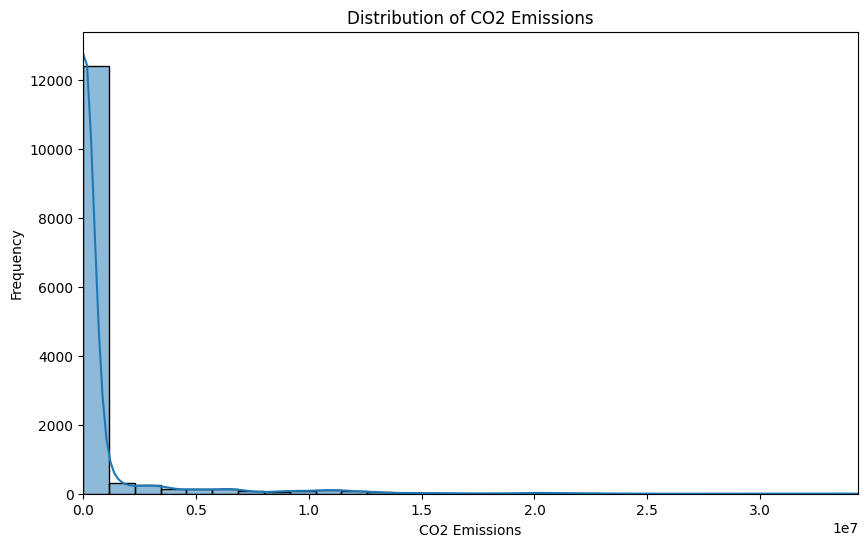

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df_co2['CO2_Emissions'], bins=30, kde=True)
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')

# Set x-axis from minimum to maximum value in your dataset
plt.xlim(df_co2['CO2_Emissions'].min(), df_co2['CO2_Emissions'].max())

plt.show()



In [10]:
df_co2['CO2_Emissions'].head(20)


0     11092.675
1     11576.719
2     12713.489
3     12178.107
4     11840.743
5     10623.299
6      9933.903
7     12236.779
8     11378.701
9     14891.687
10    16655.514
11    14495.651
12    14055.611
13    15592.084
14    14132.618
15    10234.597
16    21862.654
17    11419.038
18     9724.884
19    10201.594
Name: CO2_Emissions, dtype: float64

In [16]:
df_co2['CO2_Emissions'].isnull().count()


np.int64(13953)

In [12]:
df_co2['CO2_Emissions'].describe()


count    1.395300e+04
mean     8.254983e+05
std      2.788923e+06
min     -8.067400e+01
25%      1.100000e+03
50%      1.390000e+04
75%      1.642779e+05
max      3.434401e+07
Name: CO2_Emissions, dtype: float64

In [13]:
# Sort CO2_Emissions in ascending order
df_co2_sorted = df_co2['CO2_Emissions'].sort_values()
df_co2_sorted.head(20)  # show the 20 smallest values


11002   -80.674
3692      0.000
12460     0.000
3693      0.000
12469     0.000
12462     0.000
12461     0.000
12459     0.000
12466     0.000
12468     0.000
12470     0.000
12467     0.000
12464     0.000
12465     0.000
12463     0.000
4229      0.000
4230      0.000
8166      0.000
8321      0.000
8165      0.000
Name: CO2_Emissions, dtype: float64

#### Analysis of CO2 Emissions Distribution

Initially, we plotted a histogram of the `CO2_Emissions` column using all the data. However, the resulting graph was misleading:

- The most frequent value appeared as **0.0** with an extremely high frequency.
- About 99% of the values seemed to lie below **500000**, which did not align with realistic country-level emissions.
- The descriptive statistics showed:
  - Minimum: -80 (likely invalid)
  - Maximum: 34,344,010
  - Median: 13,900

**Observations:**
1. The dataset contains **negative values**, which are not physically meaningful for CO2 emissions and likely represent data errors.
2. There are **extreme outliers** (up to 34 million), which compress the bulk of the data when plotting the histogram, making most countries appear as if they emit almost nothing.
3. The automatic binning in the histogram causes the bulk of realistic values to appear very small on the x-axis.

**Solution:**
- Filter out negative values to remove invalid data.
- Limit the x-axis to a reasonable range, such as up to the 99th percentile, to reduce the effect of extreme outliers.
- This allows the histogram to accurately represent the distribution of the majority of countries.


count    1.393100e+04
mean     8.268020e+05
std      2.790932e+06
min      3.667000e+00
25%      1.120000e+03
50%      1.401527e+04
75%      1.645921e+05
max      3.434401e+07
Name: CO2_Emissions, dtype: float64


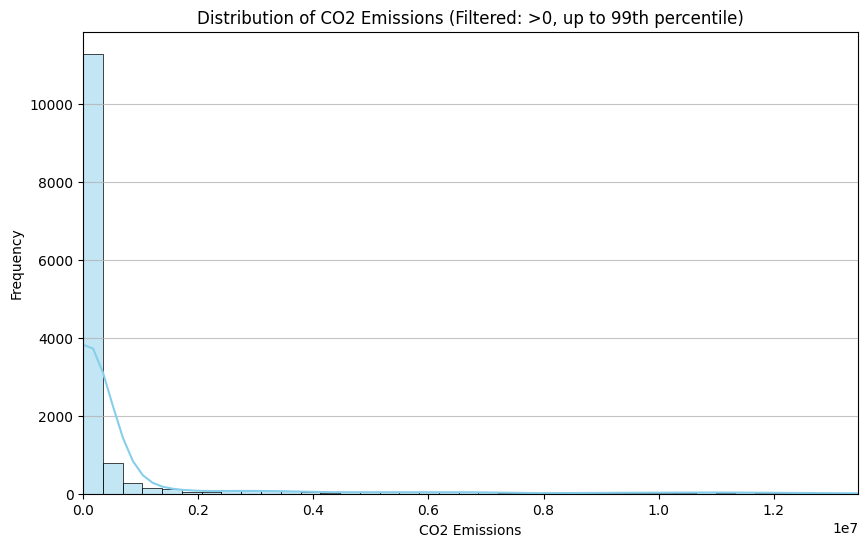

In [17]:
# Step 1: Remove negative and zero values
df_co2_filtered = df_co2[df_co2['CO2_Emissions'] > 1]

# Optional: limit to 99th percentile to avoid extreme outliers
upper_limit = df_co2_filtered['CO2_Emissions'].quantile(0.99)

# Step 2: Summary stats for filtered data
print(df_co2_filtered['CO2_Emissions'].describe())

# Step 3: Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(df_co2_filtered['CO2_Emissions'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of CO2 Emissions (Filtered: >0, up to 99th percentile)')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')
plt.xlim(0, upper_limit)
plt.grid(axis='y', alpha=0.75)
plt.show()


#### Focusing on High CO2 Emission Values

Even after removing zeros and negative values, the histogram still peaks near 0–0.2 million CO2 emissions, while the majority of higher-emitting countries appear as a flatline. This happens because:

1. **Most countries have relatively low emissions**, so when plotted on the same scale as the largest emitters, the distribution of medium- and high-emission countries gets compressed near the x-axis.
2. **Extreme outliers** (countries with very high emissions) skew the histogram, making smaller differences among high-emission countries invisible.

**Solution:**
- To better visualize the distribution of countries with significant CO2 emissions, we will filter the dataset to include only countries with emissions above a certain threshold (e.g., 200,000 or 250,000).
- This allows us to **focus on medium- and high-emitting countries**, giving a more meaningful view of the variation among them.

Filtering in this way does **not remove valid data**, it just changes the scale of the visualization so we can better interpret patterns among the highest emitters.


Rows after filter: 3006


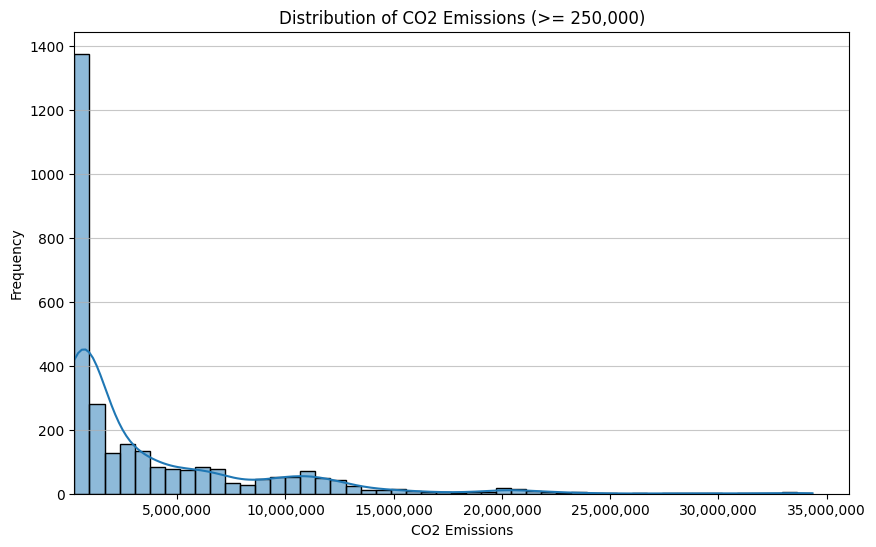

In [22]:
# Filter out zeros/negatives first
df_co2_filtered = df_co2[df_co2['CO2_Emissions'] > 0]

# Further filter for the region we want to inspect
left_bound = 250_000
df_co2_high = df_co2_filtered[df_co2_filtered['CO2_Emissions'] >= left_bound]


print("Rows after filter:", len(df_co2_high))
if df_co2_high.empty:
    print("No rows >= {:,}. Nothing to plot.".format(left_bound))
else:
    right_bound = df_co2_high['CO2_Emissions'].max()
    # Create explicit bin edges that start exactly at left_bound
    bins = np.linspace(left_bound, right_bound, 50)  # 30 bins between left and right

    # Plot into an axes object and then lock the axis limits
    fig, ax = plt.subplots(figsize=(10,6))
    sns.histplot(df_co2_high['CO2_Emissions'], bins=bins, kde=True, ax=ax)

    # Force the x-axis bounds and prevent autoscaling from changing them
    ax.set_xlim(left_bound)
    ax.set_xbound(left_bound)
    ax.set_autoscale_on(False)  # stop further autoscaling

    # nicer x tick formatting (thousands separator)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

    ax.set_title(f'Distribution of CO2 Emissions (>= {left_bound:,})')
    ax.set_xlabel('CO2 Emissions')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.7)

    plt.show()

#### Analysis of High-Emission Countries

After filtering the dataset to only include CO2 emissions greater than 250,000, the histogram gives us a clearer view of the distribution of medium- and high-emission countries.

**Key points:**
1. Most of the countries in this subset fall within the lower end of the high-emission spectrum (just above 250,000).
2. The frequency decreases as emissions increase, but there are still a few countries with extremely large values (close to the right boundary of the graph).
3. This indicates a **right-skewed distribution**, where a small number of countries contribute disproportionately high emissions compared to the majority.

**Conclusion:**
- The majority of high-emitting countries cluster closer to the lower threshold (250,000–1,000,000).
- Outliers exist with much higher emissions, which highlights the unequal distribution of CO2 emissions globally.


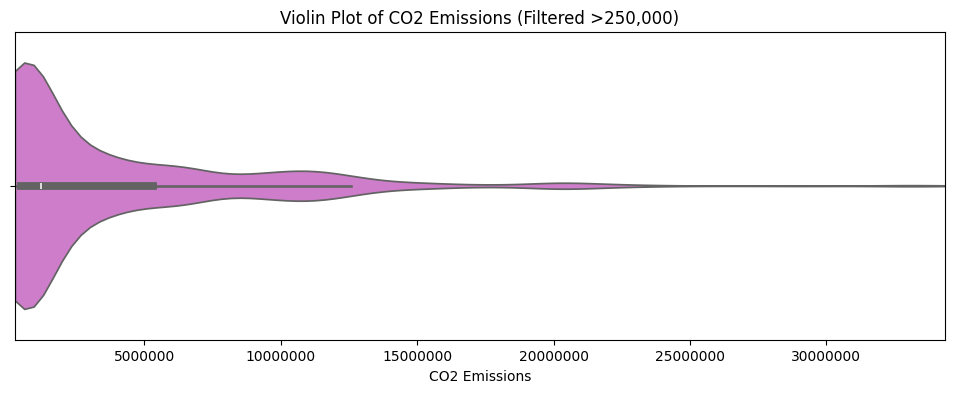

In [23]:
plt.figure(figsize=(12,4))
sns.violinplot(
    x=df_co2_high['CO2_Emissions'],
    color='orchid',
    cut=0
)

plt.title('Violin Plot of CO2 Emissions (Filtered >250,000)')
plt.xlabel('CO2 Emissions')

# Start x-axis at 250,000
plt.xlim(250000, df_co2_high['CO2_Emissions'].max())

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='x')

plt.show()

#### Violin Plot of CO₂ Emissions (Filtered >250,000)

To better visualize the distribution of very high CO₂ emissions, we used a **violin plot**.  
- The x-axis starts at **250,000**, avoiding the distortion caused by smaller values.
- The shape of the violin highlights where emissions are most densely concentrated, while still showing the long tail of extreme outliers.  

This provides a smoother and more intuitive view compared to a boxplot, which can appear distorted with highly skewed data.


#### Global CO₂ Emissions Over Time

The dataset also includes summary rows where `country_name` is set to **"World"**, representing the total global CO₂ emissions for each year.  
To better understand the global trend, we isolate these rows and plot emissions across time.  

This allows us to compare individual country emissions with the overall global emissions and see how worldwide output has evolved historically.


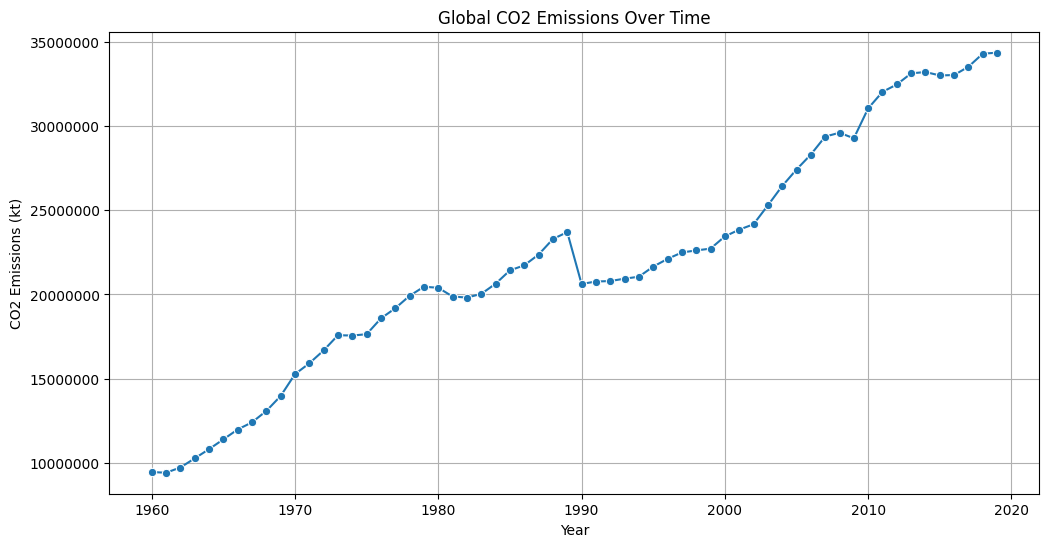

In [24]:
# Filter dataset for World summary values
df_co2_world = df_co2[df_co2['country_name'] == 'World']

# Plot CO2 emissions over time for the world
plt.figure(figsize=(12,6))
sns.lineplot(data=df_co2_world, x='year', y='CO2_Emissions', marker='o')

plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (kt)')
plt.ticklabel_format(style='plain', axis='y')  # remove scientific notation
plt.grid(True)

plt.show()


#### Why Did Global Emissions Drop in 1990?

After spotting a sharp decline in global CO₂ emissions between **1989 and 1990**, 
I looked at specific country data.  

For example, Russia (formerly part of the Soviet Union) shows a dramatic fall:  


#### Russia’s CO₂ Emissions (1980–2000)

The chart below shows Russia’s emissions over two decades.  
From 1980 to 1989, emissions were stable at very high levels, close to **4,000,000 kt**.  
In **1990**, emissions collapsed by nearly half, and remained low throughout the 1990s.  

This sharp drop aligns with the **economic and industrial collapse** following the 
end of the Soviet Union, which strongly influenced the global emissions total.

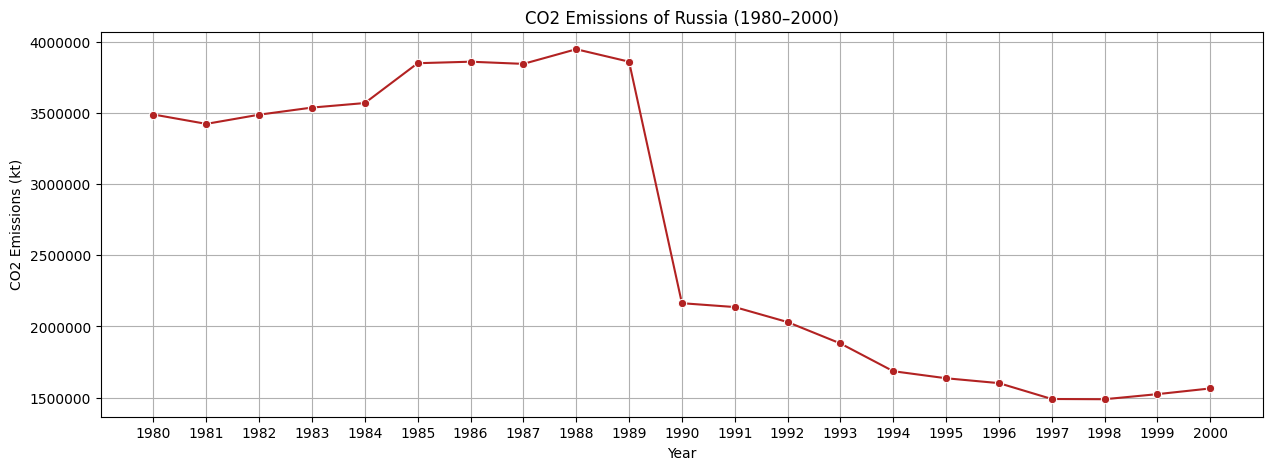

In [26]:
# Filter Russia data between 1980 and 2000
df_co2_russia_long = df_co2[
    (df_co2['country_code'] == 'RUS') &
    (df_co2['year'].between(1980, 2000))
]

# Plot line chart
plt.figure(figsize=(15,5))
sns.lineplot(data=df_co2_russia_long, x='year', y='CO2_Emissions', marker='o', color='firebrick')

plt.title('CO2 Emissions of Russia (1980–2000)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (kt)')
plt.ticklabel_format(style='plain', axis='y')  # remove scientific notation
plt.grid(True)

# Fix x-axis ticks: show every year
plt.xticks(np.arange(1980, 2001, 1))

plt.show()


This single change represents a drop of nearly **1.7 million kt**, 
which is enough to significantly influence the global totals.  

The timing coincides with the **collapse of the Soviet Union** and the 
economic/industrial breakdown in Eastern Europe and Russia.  
This confirms that the global decline was driven not by gradual 
environmental policy, but by a sudden geopolitical and economic shock. 

### 8. Conclusion on CO₂ Emissions Dataset

From the analysis, several key insights emerged:

1. **Data quality issues:**  
   - Some rows contained `0` or even negative values.  
   - The dataset also included aggregated regions and income groups, which overlap with country totals.  
   - These anomalies had to be filtered or acknowledged to avoid misleading results.  

2. **Global emissions trends:**  
   - The global emissions chart shows steady growth through most of the 20th century,  
     with a sharp drop in **1990**.  
   - Investigation revealed that this was largely driven by the collapse of the **Soviet Union**,  
     where Russia’s emissions fell dramatically as industry contracted.  

3. **Historical context:**  
   - The 1990 drop was not a result of environmental policies but of **geopolitical and economic events**.  
   - This demonstrates how political change can have as much impact on global emissions as policy or technology.  

**Next steps:**  
We will now proceed to analyze the next dataset to compare or complement these findings.
